In [1]:
#import libraries

#image management
from photutils.aperture import EllipticalAperture
from photutils.aperture import EllipticalAnnulus
from photutils.aperture import aperture_photometry
from photutils.centroids import centroid_com
from astropy.nddata import Cutout2D
from photutils.segmentation import detect_sources
from astropy.visualization import ZScaleInterval, ImageNormalize
from photutils.background import Background2D, MedianBackground

#plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib_scalebar.scalebar import ScaleBar

#astro handeling
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyregion
import sep

#math
import numpy as np
from astropy.visualization import simple_norm
from astropy.stats import SigmaClip

#data frame handeling
import pandas as pd

#pdf handeling
from matplotlib.backends.backend_pdf import PdfPages

#exception handeling
import warnings
warnings.simplefilter('ignore')

#custom stuff
import Galaxy_info as gi
import utils

In [2]:
#galaxies
galaxy_id = ["WLM", "IC 10", "NGC 4214", "UGC 8508", "DDO 50", "DDO 53"]

#file data
file = gi.Galaxy_Info[galaxy_id[0]]

#galaxy name
galaxy = file[0]

#hi file
hi_fits = file[1]

#ha file
ha_fits = file[2]

#ha csv file
ha_csv = file[3]

#irac file
irac_fits = file[4]

#irac csv file
irac_csv = file[5]

#region file
region_file = file[6]

#distance to galxy kpc
distance = file[7]

In [3]:
#load csvs and regions

#load ha csv
ha_df = pd.read_csv(ha_csv)

#load irac csv
irac_df = pd.read_csv(irac_csv)

#load regions
regions = pyregion.open(region_file)

In [4]:
#data frame and regions tests

In [5]:
# Load images

###hi image###
##############
#open hi fits file
hdu_hi = fits.open(hi_fits)

#read in hi header
header_hi = hdu_hi[0].header

#read in hi image as numpy array
hi_image = hdu_hi[0].data

#read in wcs data
wcs_hi = WCS(header_hi)

#read in hi pixel to arcsec coversion
cdelt = "CD2_2" if "CD2_2" in header_hi else "CDELT2"
arcsec_per_pixel_hi = np.abs(header_hi[cdelt]) * 3600

###ha image###
##############
#open ha fits file
hdu_ha = fits.open(ha_fits)

#read in ha header
header_ha = hdu_ha[0].header

#read in ha image as numpy array
ha_image = hdu_ha[0].data

#correct ha image for noise
masked_ha = utils.subtract_noise(ha_image)#utils.mask_stars(ha_image)

#read in ha wcs data
wcs_ha = WCS(header_ha)

#read in ha pixel to arcsec conversion
cdelt = "CD2_2" if "CD2_2" in header_ha else "CDELT2"
arcsec_per_pixel_ha = np.abs(header_ha[cdelt]) * 3600

#get ha flux units
try:
    unit_ha = (10**header_ha["RESPONSE"])
except:
    unit_ha = 1

###irac 8 micron image###
#########################
#open irac fits file
hdu_irac = fits.open(irac_fits)

#read in irac header
header_irac = hdu_irac[0].header

#read in irac image as numpy array
irac_image = hdu_irac[0].data

#sigma threshold
sigma = 0.9 * np.max(irac_image)

#mask stars with numpy mask
masked_irac = utils.mask_stars(irac_image, sigma)

#read in irac wcs data
wcs_irac = WCS(header_irac)

#read in irac pixel to arcsec conversion
cdelt = "CD2_2" if "CD2_2" in header_irac else "CDELT2"
arcsec_per_pixel_irac = np.abs(header_irac[cdelt]) * 3600

0.10903701931238174


In [6]:
#image tests

In [7]:
#function tests

0.48375 -15.4825 94.0


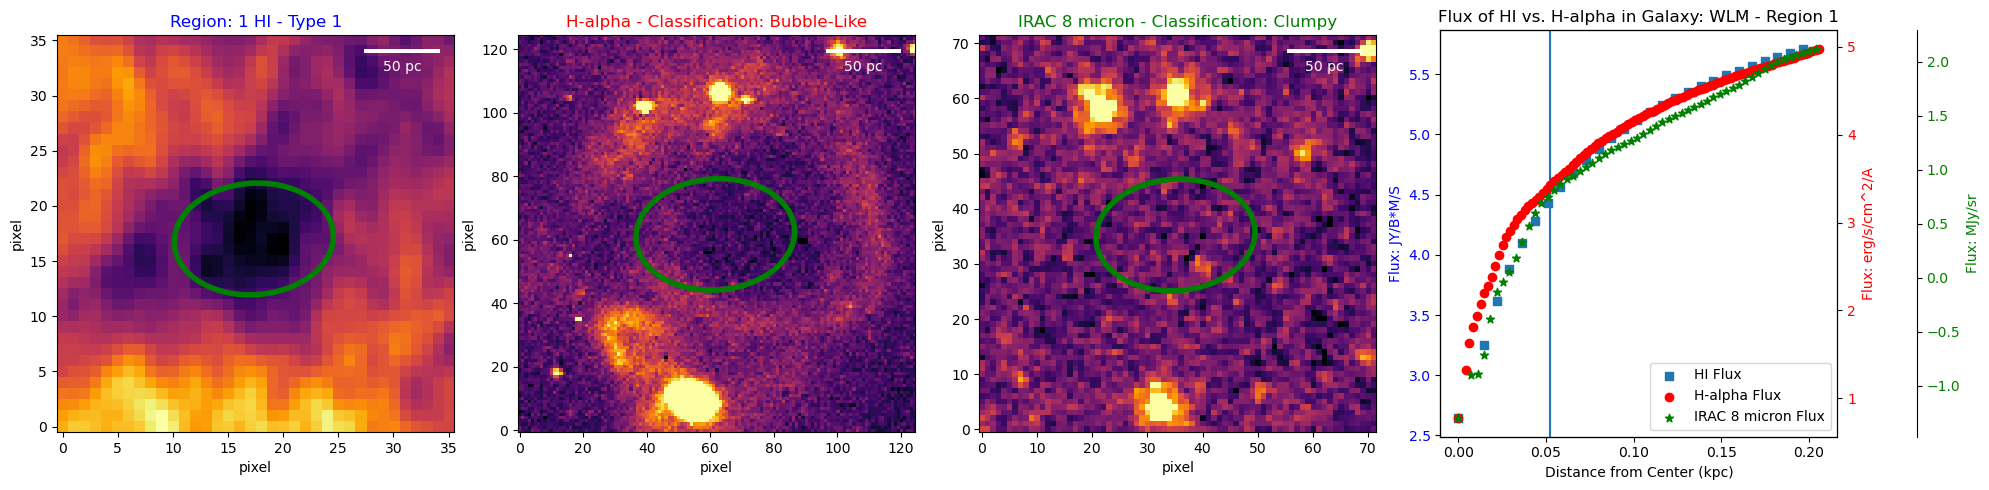

0.4937500000000001 -15.461611111111111 139.0


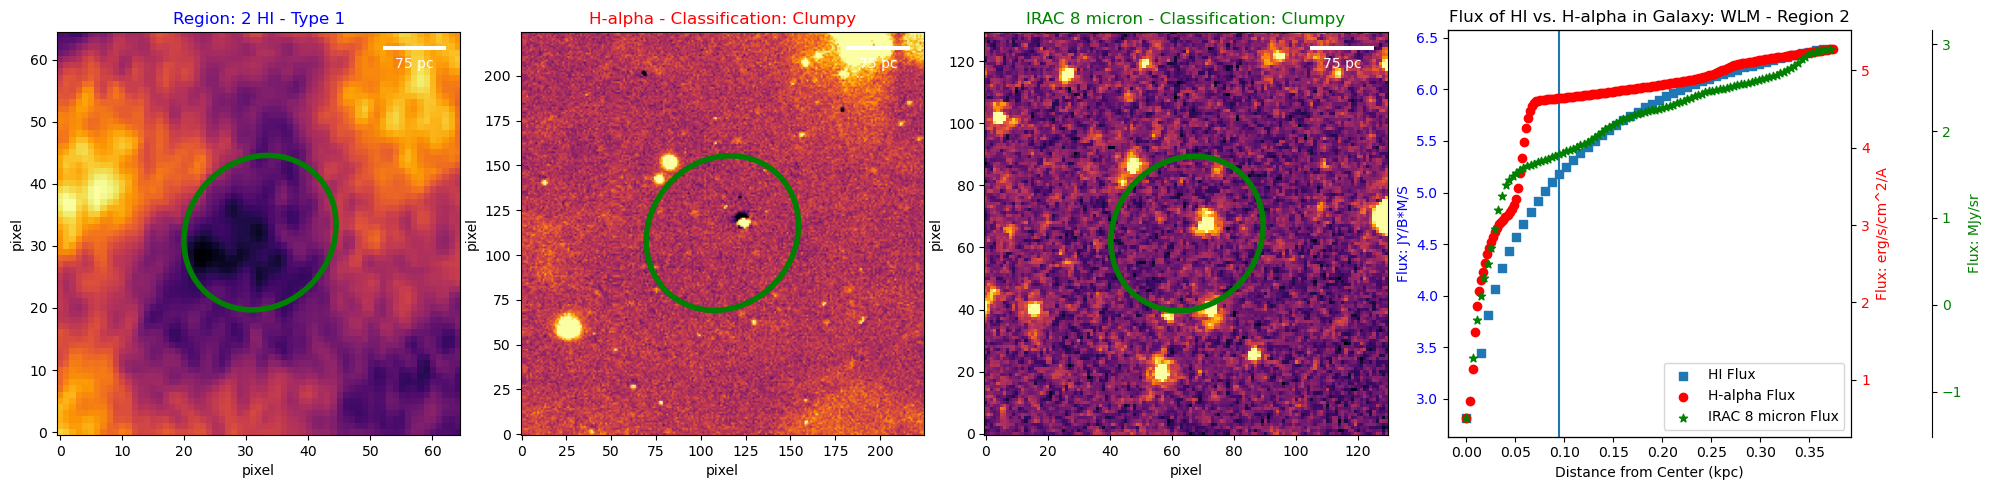

0.4954166666666667 -15.480416666666667 90.0


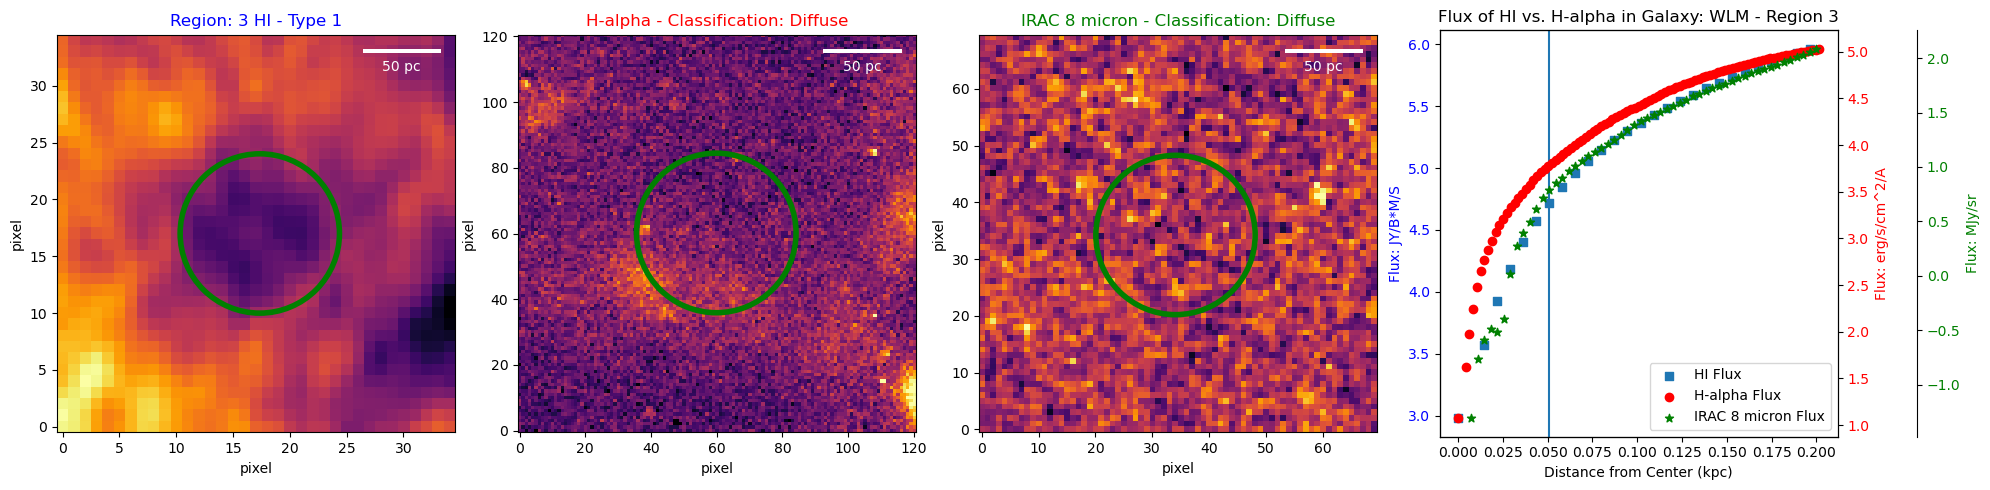

0.5154166666666666 -15.52 90.0


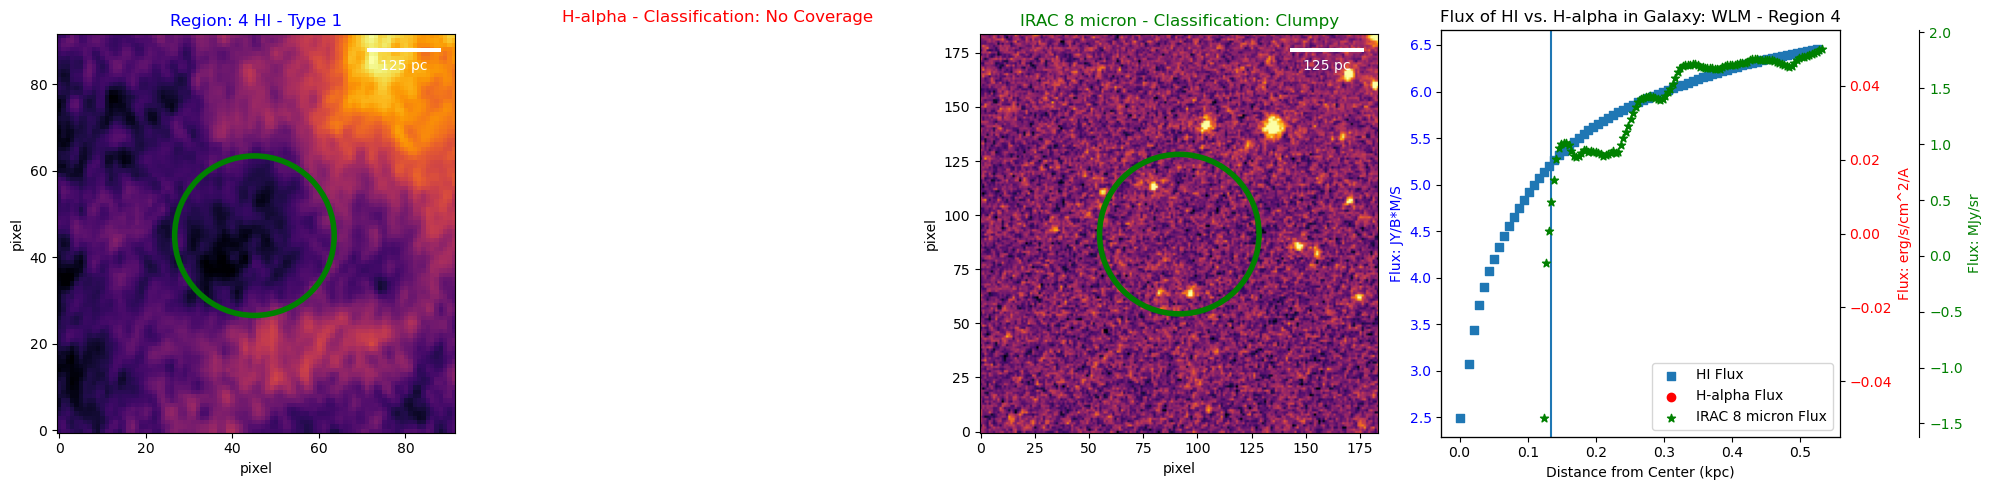

In [8]:
#initialize zscale
zscale = ZScaleInterval()

#open or create pdf
#with PdfPages(f"{galaxy}.pdf") as pdf:
if True:

    #iterate through regions
    for index, region in enumerate(regions):
    
        #check if applicable region
        if region.name != "ellipse":
            continue
    
        #grab coords of region center - coord_list: [RA, Dec, a_arcsec, b_arcsec, PA]
        ra, dec, a_arcsec, b_arcsec, pa_deg = region.coord_list
    
        #convert region center to pixel
        skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
        x_hi, y_hi = skycoord.to_pixel(wcs_hi)
        x_ha, y_ha = skycoord.to_pixel(wcs_ha)
        x_irac, y_irac = skycoord.to_pixel(wcs_irac)
    
        #convert to rads
        theta = np.deg2rad(pa_deg + 90)
        print(ra, dec, pa_deg)
    
        #convert hi arcsec → pixels
        a_pix_hi = a_arcsec * 3600/ arcsec_per_pixel_hi 
        b_pix_hi = b_arcsec * 3600/ arcsec_per_pixel_hi
    
        #convert ha arcsec → pixels
        a_pix_ha = a_arcsec * 3600/ arcsec_per_pixel_ha
        b_pix_ha = b_arcsec * 3600/ arcsec_per_pixel_ha
    
        #convert irac arcsec → pixels
        a_pix_irac = a_arcsec * 3600/ arcsec_per_pixel_irac
        b_pix_irac = b_arcsec * 3600/ arcsec_per_pixel_irac

        #initialize plot figure
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))

        #set default values
        radii_hi = radii_ha = radii_irac = 0
        flux_hi = flux_ha = flux_irac = 0

        ##########################################################
        ### HI ###################################################
        ##########################################################

        #hi cutout subplot
        ax = axs[0]

        try:
            #calculate hi flux
            radii_hi, flux_hi, rim_core_hi = utils.sum_core_to_rim_pix((x_hi, y_hi), a_pix_hi/b_pix_hi, theta, hi_image.squeeze(), \
                                                     arcsec_per_pixel_hi, a_pix_hi)

            #convert radii to kpc
            radii_hi = utils.arcsecs_to_radius(radii_hi, distance)
        
        except Exception as e:
            
            #show exception
            print(f"{index+1} HI - Flux:", e)
        
        #check if valid coords in hi
        if(x_hi>0 and y_hi>0):
    
            #get hi hole type
            hi_hole_type = ha_df["HI Hole Type"][index]

            #remove empty dimensions from hi data
            data_hi = hi_image.squeeze()

            try:

                #cut image and define region ellipse
                cutout_hi, core_ellipse = utils.cut_mark_image((x_hi, y_hi), a_pix_hi, b_pix_hi, theta, data_hi)

                #plot cutout
                utils.plot_fits(cutout_hi, arcsec_per_pixel_hi, distance, ax, core_ellipse)

            except Exception as e:

                #show exception
                print(f"{index+1} HI - Cutout:", e)
                continue

        #set hi title
        ax.set_title(f"Region: {index + 1} HI - Type {hi_hole_type}", color="blue")
        plt.tight_layout()

        ##########################################################
        ### H-alpha ##############################################
        ##########################################################

        #initialize ha cutout subplot
        ax = axs[1]
        
        #get classification
        ha_class = ha_df["Classification"][index]

        #check if coverage
        if ha_class != "No Coverage":# and ha_class != "No Emission":

            try:
                #calculate ha flux
                radii_ha, flux_ha, rim_core_ha = utils.sum_core_to_rim_pix((x_ha, y_ha), a_pix_ha/b_pix_ha, theta, masked_ha, \
                                                         arcsec_per_pixel_ha, a_pix_ha)
        
                
                #convert radii to kpc
                radii_ha = utils.arcsecs_to_radius(radii_ha, distance)

                #convert flux to erg/s/cm^2/A
                flux_ha = flux_ha * unit_ha
            
            except Exception as e:
               
                #show exception
                print(f"{index+1} Ha - Flux:", e)
        
            #check if valid coords in ha
            if (x_ha>0 and y_ha>0):

                try:
                    #cut image and define region ellipse
                    data_ha = masked_ha
                    cutout_ha, core_ellipse = utils.cut_mark_image((x_ha, y_ha), a_pix_ha, b_pix_ha, theta, data_ha)
                
                    #plot cutout
                    utils.plot_fits(cutout_ha, arcsec_per_pixel_ha, distance, ax, core_ellipse)

                except Exception as e:

                    #show exception
                    print(f"{index+1} Ha - Cutout:", e)
                    continue

        else:
            #hide blank axis
            ax.set_axis_off()

        #set ha title
        ax.set_title(f"H-alpha - Classification: {ha_class}", color="red")

        ##########################################################
        ### IRAC 8 micron ########################################
        ##########################################################

        #initialize irac flux subplot
        ax = axs[2]

        #get classification
        irac_class = irac_df["Classification"][index]

        #check if coverage
        if irac_class != "No Coverage" and irac_class != "No Emission":

            try:
                #calculate irac flux
                radii_irac, flux_irac, rim_core_irac = utils.sum_core_to_rim_pix((x_irac, y_irac), a_pix_irac/b_pix_irac, theta, masked_irac, \
                                                         arcsec_per_pixel_irac, a_pix_irac)
                
                #convert radii to kpc
                radii_irac = utils.arcsecs_to_radius(radii_irac, distance)
            
            except Exception as e:
                
                #show exception
                print(f"{index+1} IRAC- Flux:", e)

            #check if valid coords in irac
            if(x_irac>0 and y_irac>0):

                try:
                    #cut image and define region ellipse
                    data_irac = masked_irac
                    cutout_irac, core_ellipse = utils.cut_mark_image((x_irac, y_irac), a_pix_irac, b_pix_irac, theta, data_irac)

                    #plot cutout
                    utils.plot_fits(cutout_irac, arcsec_per_pixel_irac, distance, ax, core_ellipse)

                except Exception as e:

                    #show exception
                    print(f"{index+1} IRAC - Cutout:", e)
                    continue

        else:
            #hide blank axis
            ax.set_axis_off()
        
        #set irac title
        ax.set_title(f"IRAC 8 micron - Classification: {irac_class}", color="green")
        plt.tight_layout()

        ##########################################################
        ### Flux Plotting ########################################
        ##########################################################

        #plot hi flux against ha flux against irac flux
        
        #initialize hi rim
        hi_rim = utils.arcsecs_to_radius(a_pix_hi * arcsec_per_pixel_hi, distance)
        
        #plot core to rim sums for hi, ha, irac
        ax = axs[3]
        utils.plot_core_rim(radii_hi, flux_hi, radii_ha, flux_ha, radii_irac, flux_irac, ax, galaxy, index, hi_rim, unit_ha)

        #save plots
        #pdf.savefig()
        
        #tighten
        plt.tight_layout()
        
        #save plots
        #pdf.savefig()

        #show cutouts
        plt.show()
        
        #close fig
        plt.close()